In [2]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d

# import time averaging and mixing functions
from timeAvgFunction import iceTimeAvg
from mixFunction import mixIce

# set plot styles
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['lines.linestyle'] = '-'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['font.size'] = 9
mpl.rcParams['axes.linewidth'] = .5

#silence warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# load ice data
ice = pd.read_excel("blueIceData.xlsx")
# remove deepest sample which isn't considered in the original paper
ice = ice.iloc[:-1]
# we want to work with just the long snapshot data
ice = ice.loc[ice['SnapshotLong']==1].reset_index(drop=True)

## Section 1: Mixing depth determination for CO<sub>2</sub>

In [4]:
######## Make the null hypothesis "truth" CO2 dataset
# Set a threshold to remove really low (unrealistic) alkenone and paleosol proxy values.
# Using 160 here bc min CO2 from the 800 ka traditional ice core record is 173 ppm.
lowThres = 160
# Set the cutoff point in time to find and compile proxy CO2 data (in ka)
timeCut = 3800
# first load 800 ka record of traditional ice core CO2
co2 = pd.read_csv("externalData/antarctica2015co2composite-noaa.txt",sep='\t')
co2age = co2['age_gas_calBP'].to_numpy()/1000
co2ppm = co2['co2_ppm'].to_numpy()
# then load boron data - from paleo-co2.org compilation
bdata = pd.read_csv("externalData/boron_co2.csv").sort_values(by='age')
# clip to timeCut value
bdataPlio = bdata.loc[bdata['age']<timeCut].reset_index(drop=True)
ageBoron = bdataPlio["age"].to_numpy()
co2Boron = bdataPlio["co2"].to_numpy()
# load paleosol co2 data - from paleo-co2.org compilation
pdata = pd.read_csv("externalData/paleosol_co2.csv").sort_values(by='age')
# remove data points below threshold value
pdata = pdata.loc[pdata["co2"]>lowThres].reset_index(drop=True)
agePaleo = pdata["age"].to_numpy()
co2Paleo = pdata["co2"].to_numpy()
# load alkenone co2 data - from paleo-co2.org compilation
alkCO2 = pd.read_csv("externalData/alkenone_co2.csv")
# clip and remove data points below threshold value
alkCO2 = alkCO2.loc[(alkCO2['age']<timeCut) & (alkCO2['co2']>lowThres)].reset_index(drop=True)
ageAlk = alkCO2["age"].to_numpy()
co2Alk = alkCO2["co2"].to_numpy()
# make a composite CO2 record using ice for < 800 ka then other proxies beyond
# boron
bages = ageBoron[ageBoron > co2age.max()]
bdats = co2Boron[ageBoron > co2age.max()]
# alkenone
aages = ageAlk[ageAlk > co2age.max()]
adats = co2Alk[ageAlk > co2age.max()]
# paleosol is only 1-3 Ma so doesn't need clipping
# concatenate together
compCO2age = np.concatenate((co2age,bages,agePaleo,aages))
compCO2 = np.concatenate((co2ppm,bdats,co2Paleo,adats))
indices = np.argsort(compCO2age)
compCO2age = compCO2age[indices]
compCO2 = compCO2[indices]
# resample the dataset to an even time step to avoid aliasing during forward modeling
# let's do 10 ka
tstep = 10
CO2dAge = np.arange(0,np.max(compCO2age),tstep)
CO2dVal = np.interp(CO2dAge,compCO2age,compCO2)

In [5]:
######### TIME AVERAGING 
# apply the time averaging function
CO2sim = iceTimeAvg(ice.Age, ice.AgeErrA, 400, CO2dAge,CO2dVal,1000)

###### MIXING
# compute middle depth
dmid = ice[['TopDepth', 'BottomDepth']].mean(axis=1)
# mix co2, use 10 cm as the dstep (mean sample width)
dstep = 0.1
mixTest = np.linspace(0.4,1.1,15)
mixArray = np.zeros((CO2sim.shape[0],CO2sim.shape[1],len(mixTest)))
# test different mixing depths
for i in range(len(mixTest)):
    _, _, _, mixNow = mixIce(dmid,dstep,CO2sim,mixTest[i])
    mixArray[:,:,i] = mixNow

In [ ]:
######## COMPUTE VARIANCES (AND OTHER STATS)
co2pres = ~np.isnan(ice.CO2m)
prist = ice.NotPristine == 0
co2p = ice.CO2m[prist]
co2p = np.where(~np.isnan(ice.CO2dC[prist]), ice.CO2dC[prist], ice.CO2m[prist])
agep = ice.Age[prist]
pleistoDats = co2p[(agep < 2500) & (~np.isnan(co2p))]
idx = prist & co2pres & (ice.Age < 2500)

# data variance
icevar = np.var(pleistoDats, ddof=1)
icevarerr = np.sqrt((2 * (icevar**2)) / (len(pleistoDats) - 1))

# simulated variance and other stats
simvar = np.zeros((len(mixTest)))
rmse = np.zeros((len(mixTest)))
corr = np.zeros((len(mixTest)))
for i in range(len(mixTest)):
    simvar[i] = np.var(mixArray[idx,:,i], ddof=1)
    rmse[i] = np.sqrt(np.mean(np.square(pleistoDats - np.mean(mixArray[idx,:,i],1))))
    corrmatrix = np.corrcoef(pleistoDats,np.mean(mixArray[idx,:,i],1))
    corr[i] = corrmatrix[0, 1]


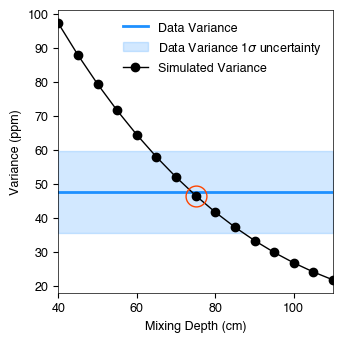

In [55]:
######### FIGURE S1
cM = mixTest*100
xlims = (np.min(cM),np.max(cM))
fig = plt.figure(figsize=(3.5,3.5))
ax = fig.add_subplot(1,1,1)
ax.plot(cM,np.tile(icevar,len(mixTest)),color="dodgerblue",linewidth=2,label="Data Variance",zorder=2)
ax.fill_between(cM,np.tile(icevar,len(mixTest))-icevarerr,np.tile(icevar,len(mixTest))+icevarerr,color="dodgerblue",alpha=.2,label="Data Variance 1$\sigma$ uncertainty",zorder=1)
ax.plot(cM,simvar,marker='o',markersize=6,color="black",linewidth=1,label="Simulated Variance",zorder=3)
ax.plot(cM[cM==75],simvar[cM==75],marker='o',markerfacecolor="None",markeredgecolor="orangered",markersize=15,zorder=4)
ax.legend(loc='upper right',frameon=False)#, fontsize=8)
ax.set_xlim(xlims)
ax.set_xlabel("Mixing Depth (cm)")
ax.set_ylabel("Variance (ppm)")

fig.tight_layout()
fig.savefig("outputFigures/MixingDepthCO2.pdf", bbox_inches="tight")

## Section 2: Mixing depth determination for d2H in ice

In [7]:
###### CREATE D2H NULL "TRUTH" DATASET
# read in lr04 and also Epica Dome C dD data
lr04 = pd.read_excel("externalData/lisiecki2005-d18o-stack-noaa.xlsx")
edcD = pd.read_excel("externalData/edc3deuttemp2007-noaa.xlsx")
# normalize LR04 in the same age range as EDC
lrCut = lr04.loc[lr04['Age']<= max(edcD.Age/1000)]
lrNorm = -(lr04.d18Ob - np.mean(lrCut.d18Ob))/np.std(lrCut.d18Ob)
# add back stdev from EDC Deuterium, adjust mean to match the group of blue ice measurements younger than 800 ka (EDC span)
lrEDC = lrNorm * np.std(edcD.Deuterium) + np.mean(ice.dDice[ice.Age < 800])
ageLR04 = lr04['Age'].to_numpy()

In [ ]:
###### TIME AVERAGING AND MIXING OF D2H
dDSim = iceTimeAvg(ice.Age, ice.AgeErrA, 400, ageLR04,lrEDC,1000)
# mix - sample step is still 10 cm as with CO2
mixTest = np.linspace(0.1,0.7,13)
mixArray = np.zeros((dDSim.shape[0],dDSim.shape[1],len(mixTest)))
# test different mixing depths
for i in range(len(mixTest)):
    _, _, _, mixNow = mixIce(dmid,dstep,dDSim,mixTest[i])
    mixArray[:,:,i] = mixNow

In [20]:
######## COMPUTE VARIANCES (AND OTHER STATS)
dDpres = ~np.isnan(ice.dDice)
dDats = ice.dDice[dDpres]
# data variance
icevar = np.var(dDats,ddof=1)
icevarerr = np.sqrt((2 * (icevar**2)) / (len(dDats) - 1))

# simulated variance and other stats
simvar = np.zeros((len(mixTest)))
rmse = np.zeros((len(mixTest)))
corr = np.zeros((len(mixTest)))
for i in range(len(mixTest)):
    simvar[i] = np.var(mixArray[dDpres,:,i], ddof=1)
    rmse[i] = np.sqrt(np.mean(np.square(dDats - np.mean(mixArray[dDpres,:,i],1))))
    corrmatrix = np.corrcoef(dDats,np.mean(mixArray[dDpres,:,i],1))
    corr[i] = corrmatrix[0, 1]

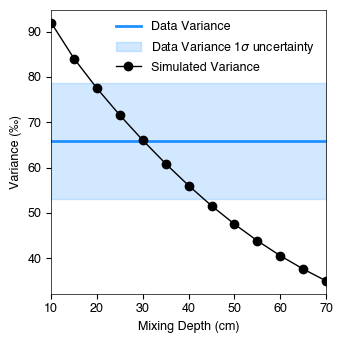

In [22]:
######### FIGURE
cM = mixTest*100
xlims = (np.min(cM),np.max(cM))
fig = plt.figure(figsize=(3.5,3.5))
ax = fig.add_subplot(1,1,1)
ax.plot(cM,np.tile(icevar,len(mixTest)),color="dodgerblue",linewidth=2,label="Data Variance",zorder=2)
ax.fill_between(cM,np.tile(icevar,len(mixTest))-icevarerr,np.tile(icevar,len(mixTest))+icevarerr,color="dodgerblue",alpha=.2,label="Data Variance 1$\sigma$ uncertainty",zorder=1)
ax.plot(cM,simvar,marker='o',markersize=6,color="black",linewidth=1,label="Simulated Variance",zorder=3)
ax.plot(cM[cM==75],simvar[cM==75],marker='o',markerfacecolor="None",markeredgecolor="orangered",markersize=15,zorder=4)
ax.legend(loc='upper right',frameon=False)#, fontsize=8)
ax.set_xlim(xlims)
ax.set_xlabel("Mixing Depth (cm)")
ax.set_ylabel("Variance (‰)")

fig.tight_layout()
fig.savefig("outputFigures/MixingDepthd2H.pdf", bbox_inches="tight")

## Section 3: Iteration of mixing depth for MOT

In [23]:
###### CREATE NULL TRUTH DATASET FOR MOT
# for this we will first forward model from a "truth" MOT record based on scaling LR04 to EDC MOT (from Kr/N2)
# read in lr04 and also EDC dD data
edcMOT = pd.read_excel("externalData/edc2021noblegastemp.xlsx")
# normalize LR04 in the same age range as EDC
lrCut = lr04.loc[lr04['Age']<= max(edcMOT.Age)]
lrNorm = -(lr04.d18Ob - np.mean(lrCut.d18Ob))/np.std(lrCut.d18Ob)
# add back stdev from EDC Deuterium, adjust mean to match the youngest group of MOT measurements
lrMOT = lrNorm * np.std(edcMOT.MOTKrN2) + np.mean(ice.MOT[ice.Age < 800])

In [67]:
######## TIME AVERAGING AND MIXING OF MOT
# time average
MOTSim = iceTimeAvg(ice.Age, ice.AgeErrA, 400, ageLR04, lrMOT, 1000)
# mix - sample step is still 10 cm as with CO2
mixTest = np.linspace(0.05,0.6,12)
mixArray = np.zeros((MOTSim.shape[0],MOTSim.shape[1],len(mixTest)))
# test different mixing depths
for i in range(len(mixTest)):
    _, _, _, mixNow = mixIce(dmid,dstep,MOTSim,mixTest[i])
    mixArray[:,:,i] = mixNow
# in the case of MOT we need to add an additional error term associated with inference from Xe/Kr
# we can use the relative error column in the provided data set as a 1-sigma error
MOTpres = ~np.isnan(ice.MOT)
MOTdats = mixArray[MOTpres,:,:]
# MC sampling of this err
N = 1000
M = MOTdats.shape[0]
P = MOTdats.shape[2]
MOTerrs = np.atleast_2d(ice.MOTErr[MOTpres].to_numpy()).T
MOTerrs = np.repeat(MOTerrs,N,axis=1)
MOTerrs = np.tile(MOTerrs[:,:,np.newaxis],P)
MOTrndE = np.random.normal(np.zeros((M,N,P)),MOTerrs)#,size=(M,N,P))
# add error to final ensembles
MOTTot = MOTdats + MOTrndE

In [68]:
######## COMPUTE VARIANCES (AND OTHER STATS)
MOTDats = ice.MOT[MOTpres]
# data variance
icevar = np.var(MOTDats,ddof=1)
icevarerr = np.sqrt((2 * (icevar**2)) / (len(MOTDats) - 1))

# simulated variance and other stats
simvar = np.zeros((len(mixTest)))
rmse = np.zeros((len(mixTest)))
corr = np.zeros((len(mixTest)))
for i in range(len(mixTest)):
    simvar[i] = np.var(MOTTot[:,:,i], ddof=1)
    rmse[i] = np.sqrt(np.mean(np.square(MOTDats - np.mean(MOTTot[:,:,i],1))))
    corrmatrix = np.corrcoef(MOTDats,np.mean(MOTTot[:,:,i],1))
    corr[i] = corrmatrix[0, 1]

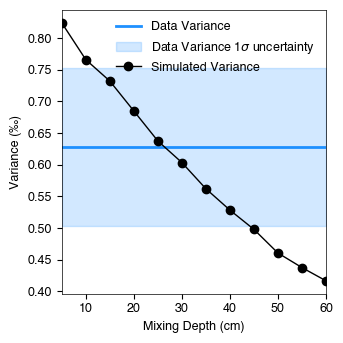

In [69]:
######### FIGURE
cM = mixTest*100
xlims = (np.min(cM),np.max(cM))
fig = plt.figure(figsize=(3.5,3.5))
ax = fig.add_subplot(1,1,1)
ax.plot(cM,np.tile(icevar,len(mixTest)),color="dodgerblue",linewidth=2,label="Data Variance",zorder=2)
ax.fill_between(cM,np.tile(icevar,len(mixTest))-icevarerr,np.tile(icevar,len(mixTest))+icevarerr,color="dodgerblue",alpha=.2,label="Data Variance 1$\sigma$ uncertainty",zorder=1)
ax.plot(cM,simvar,marker='o',markersize=6,color="black",linewidth=1,label="Simulated Variance",zorder=3)
ax.plot(cM[cM==75],simvar[cM==75],marker='o',markerfacecolor="None",markeredgecolor="orangered",markersize=15,zorder=4)
ax.legend(loc='upper right',frameon=False)#, fontsize=8)
ax.set_xlim(xlims)
ax.set_xlabel("Mixing Depth (cm)")
ax.set_ylabel("Variance (‰)")

fig.tight_layout()
fig.savefig("outputFigures/MixingDepthMOT.pdf", bbox_inches="tight")